# Sparse physics-informed atomistic-edit ptychography at glancing incidence

The reconstruction in this notebook asks for the smallest data-supported change to a known, deformable silicon host. Sparse host removals and continuous positive scattering centres represent vacancies, substitutions, interstitials, adatoms, and irregular added material without an object flag or shape model:

$$
V(\mathbf r)=\sum_i(1-b_i)v_{\mathrm{Si}}\!\left(\mathbf r-\mathbf R_i^0-\mathbf u(\mathbf R_i^0)\right)+\sum_j a_jv_{\mathrm{eff}}(\mathbf r-\mathbf x_j).
$$

Here $0\le b_i\le1$, $a_j\ge0$ is reported only in host-equivalent integrated-scattering units, and the maintained side view fits two continuous coordinates per added centre. The calibrated count likelihood, weak host elasticity, occupancy-weighted hard-core barrier, and one edit-mass penalty constrain the inverse problem. This remains conditional structure recovery with known host species, orientation, registration, probe, and slab geometry—not unconstrained chemistry identification or a trusted experimental structure solution.


In [1]:
%matplotlib widget

import jax
import numpy as np
from IPython.display import display

from wide_angle_propagation.notebook_utils import resolve_repo_root
from wide_angle_propagation.ptychography_workflow_1d import (
    SiliconGlancingConfig1D,
    build_silicon_glancing_experiment_1d,
    make_glancing_scan_viewer_1d,
    plot_experiment_overview_1d,
    simulate_experiment_1d,
)

jax.config.update("jax_enable_x64", True)


## 1. Construct the matched experiment

`SiliconGlancingConfig1D` keeps the physical and numerical defaults in one place. The default `update_region="auto"` traces the known Gaussian probes from their input coordinates and angle. It distinguishes the uncertainty-expanded forward interaction volume from a TARGET discovery volume defined by nominal geometry and training scans only. Validation, audit, and guard scans can therefore test a fitted structure but cannot make an otherwise unsupported atom reportable. The host catalogue marks any non-target Si site whose padded patch touches the forward volume as NUISANCE candidate support. Sparse AE removals at those sites remain in the forward fit but are never presented as recovered structure; sites without active edits stay fixed in the authenticated reference host. Fixed exterior material is allowed only with explicit provenance.


In [2]:
config = SiliconGlancingConfig1D(
    update_region="auto",
    exterior_material_policy="parameterize_uncertain",
    atomic_template_cutoff_A=None,
)
experiment = build_silicon_glancing_experiment_1d(config)
host_support = experiment.support_contract
interaction = experiment.interaction_region
experiment_setup_summary = {
    "potential shape": tuple(np.asarray(experiment.pristine_potential).shape),
    "sampling (ds, du) A": (experiment.axial_sampling, experiment.transverse_sampling),
    "scan count": len(experiment.window_starts),
    "training scans": len(experiment.training_indices),
    "validation scans": len(experiment.validation_indices),
    "audit scans": len(experiment.audit_indices),
    "guard scans": len(experiment.guard_indices),
    "update region": experiment.config.update_region,
    "forward interaction pixels": int(np.count_nonzero(interaction.forward_mask)),
    "excluded probe power": interaction.excluded_probe_power,
    "nominal mutable interaction radius (A)": interaction.nominal_radius_A,
    "uncertainty-expanded forward interaction radius (A)": interaction.radius_A,
    "geometry uncertainty margin (A)": interaction.uncertainty_margin_A,
    "minimum training-scan coverage": interaction.minimum_scan_coverage,
    "exterior material policy": host_support.exterior_policy,
    "fixed exterior provenance": host_support.fixed_material_provenance_id,
    "material support contract": host_support.contract_id,
    "material scope complete": host_support.strict_requirements_satisfied,
    "atomic template cutoff (A)": experiment.template_certification.cutoff_A,
    "atomic template relative tail L2": experiment.template_certification.relative_tail_l2,
    "known host TARGET sites": len(host_support.target_site_indices),
    "known host NUISANCE sites": len(host_support.nuisance_site_indices),
    "known modeled host sites": len(host_support.modeled_site_indices),
}
experiment_setup_summary


{'potential shape': (2946, 2318),
 'sampling (ds, du) A': (0.3394375, 0.1467837837837838),
 'scan count': 300,
 'training scans': 243,
 'validation scans': 27,
 'audit scans': 30,
 'guard scans': 0,
 'update region': 'auto',
 'forward interaction pixels': 259260,
 'excluded probe power': 1e-05,
 'nominal mutable interaction radius (A)': 9.370239823022626,
 'uncertainty-expanded forward interaction radius (A)': 9.370239823022626,
 'geometry uncertainty margin (A)': 0.0,
 'minimum training-scan coverage': 3,
 'exterior material policy': 'parameterize_uncertain',
 'fixed exterior provenance': None,
 'material support contract': 'b4ca4ee25302caba79d93174204cf7b572c1cfecbb867db235890c998ca8bf50',
 'material scope complete': True,
 'atomic template cutoff (A)': 5.0,
 'atomic template relative tail L2': 2.9758933172903423e-07,
 'known host TARGET sites': 3607,
 'known host NUISANCE sites': 1497,
 'known modeled host sites': 5104}

The automatic support converts an excluded Gaussian probe-power budget into a transverse radius and evaluates nominal training-scan coverage throughout the slab. A digest-bound contract labels every catalogued site as TARGET, NUISANCE, fixed-known, below the declared interaction budget, or unresolved. TARGET selection uses the site center in the nominal training-only mask; padded patch footprints determine forward relevance and therefore nuisance sites. Position and angle uncertainty expand only that forward/nuisance support through a spatially local envelope of bounded rays. AE plots and GIFs rerender the TARGET component and reset nuisance edits to pristine, while the stored full potential retains nuisance scattering as a labelled forward-fit diagnostic. The atomic-template radius is selected automatically from a larger isolated-Si reference; `experiment.template_certification` reports the selected cutoff, tail error, tolerance, and tested candidates. Reconstruction size is reported later from the active sparse AE state as `P_deformation + K_- + 3 K_+`.


## 2. Simulate one truth case

Three matched cases are available: `"vacancy"`, `"vacancy_plus_strain"`, and `"strained_surface_defects"`. The last case combines an irregular pit extending through three surface layers, two satellite vacancy clusters, and a two-lobed depth-dependent displacement field. It is harder, but remains representable by the stated vacancy-and-smooth-strain model. The returned dataset reports the severe error caused by deleting exterior material, the certified Lobato cutoff error, and a separate Kirkland-versus-Lobato model-sensitivity diagnostic. The Kirkland atom is integrated directly over each pixel and finite projection width, but the alternative specimen still shares accumulation, displacement rendering, and propagation. It therefore has no acceptance threshold, is excluded from cutoff certification, and is not independent experimental validation.


In [3]:
DATASET_CASE = "strained_surface_defects"
dataset = simulate_experiment_1d(experiment, DATASET_CASE, batch_size=10)

{
    **experiment_setup_summary,
    "zero-exterior amplitude NRMSE": dataset.zero_exterior_amplitude_nrmse,
    "template-cutoff amplitude NRMSE": dataset.template_cutoff_amplitude_nrmse,
    "template certified worst-scan amplitude NRMSE": (
        dataset.template_certified_worst_amplitude_nrmse
    ),
    "Kirkland alternative amplitude NRMSE": (
        dataset.kirkland_alternative_amplitude_nrmse
    ),
    "Kirkland alternative worst-scan amplitude NRMSE": (
        dataset.kirkland_alternative_max_scan_amplitude_nrmse
    ),
    "support contract ID": experiment.support_contract.contract_id,
}


{'potential shape': (2946, 2318),
 'sampling (ds, du) A': (0.3394375, 0.1467837837837838),
 'scan count': 300,
 'training scans': 243,
 'validation scans': 27,
 'audit scans': 30,
 'guard scans': 0,
 'update region': 'auto',
 'forward interaction pixels': 259260,
 'excluded probe power': 1e-05,
 'nominal mutable interaction radius (A)': 9.370239823022626,
 'uncertainty-expanded forward interaction radius (A)': 9.370239823022626,
 'geometry uncertainty margin (A)': 0.0,
 'minimum training-scan coverage': 3,
 'exterior material policy': 'parameterize_uncertain',
 'fixed exterior provenance': None,
 'material support contract': 'b4ca4ee25302caba79d93174204cf7b572c1cfecbb867db235890c998ca8bf50',
 'material scope complete': True,
 'atomic template cutoff (A)': 5.0,
 'atomic template relative tail L2': 2.9758933172903423e-07,
 'known host TARGET sites': 3607,
 'known host NUISANCE sites': 1497,
 'known modeled host sites': 5104,
 'zero-exterior amplitude NRMSE': 0.1406334120716704,
 'templat

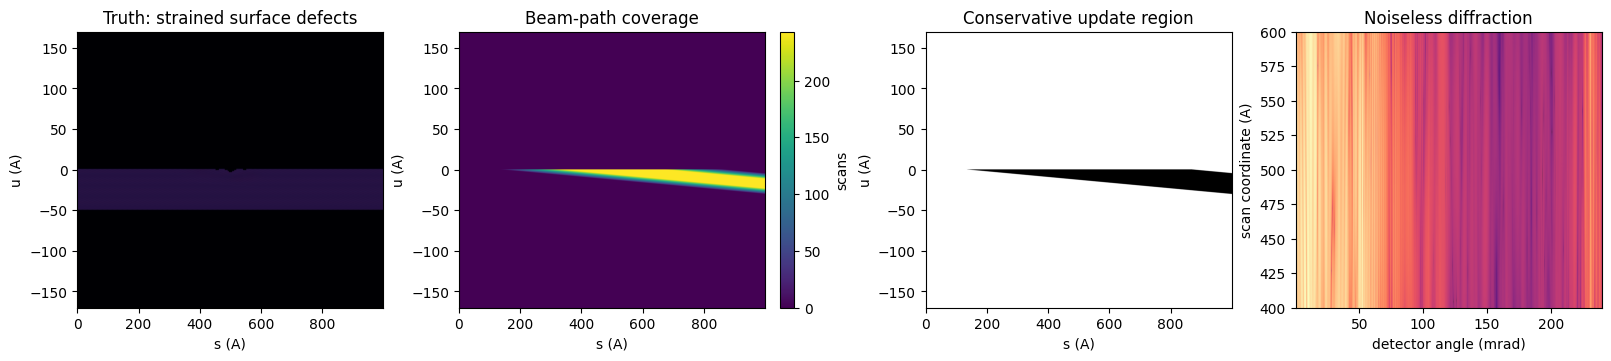

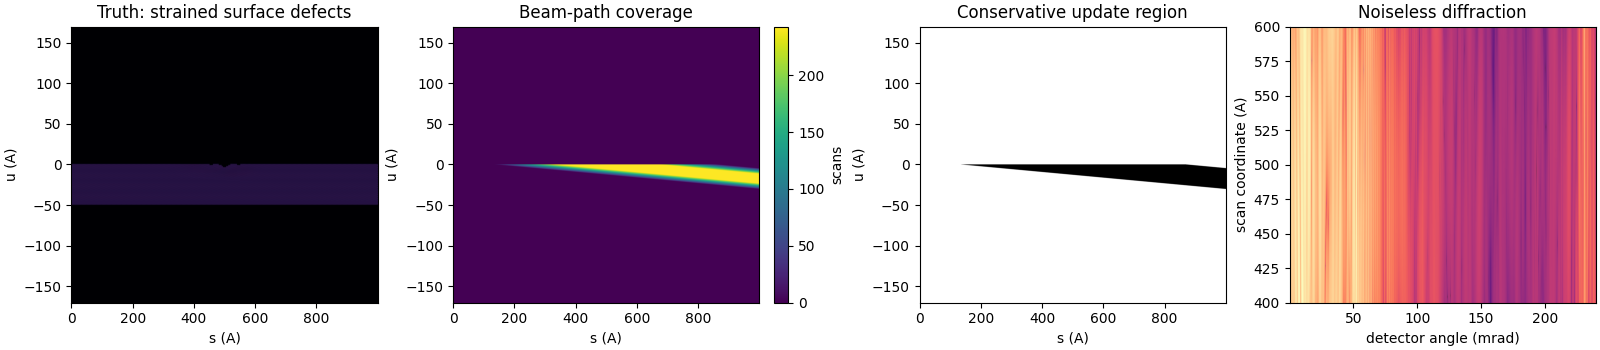

In [4]:
plot_experiment_overview_1d(experiment, dataset)


## 3. Explore the scan before inversion

The linked viewer is deliberately placed before the reconstruction. The slider changes the beam landing position, while the three panels retain the original global side view, exit-wave intensity, and positive-angle diffraction signal. Setting `scan_stride` above one stores fewer side views and enables the checkbox for on-demand positions.


In [5]:
scan_viewer = make_glancing_scan_viewer_1d(
    experiment,
    dataset,
    scan_stride=20,
)
scan_viewer


## 4. Sparse atomistic-edit reconstruction

This is the notebook's only specimen reconstruction path. The broad surface envelope is a geometry-derived search domain, not an object boundary. Nominal training coverage defines reportable TARGET anchors; uncertainty-expanded held-out coverage can create fitted, non-reportable NUISANCE anchors. Static capacities are compilation/resource bounds, while the reported active count is $P_{\mathrm{deformation}}+K_-+3K_+$.

The committed notebook runs a bounded mechanics profile, not an acceptance reconstruction. It uses full-training proposal scores and deliberately few joint refinements with TQDM. Validation selects the penalty-path point and audit counts are opened only afterward. The smoke profile may stop unconverged or at capacity on the 34-site surface-defect truth; that is a truthful fail-closed outcome, not evidence that the structure was recovered. Set `RUN_ATOMISTIC_EDIT=False` when only regenerating the experiment diagnostics.


### 4.1 Calibrated, bounded configuration

The measurement boundary contains calibrated non-negative electron-equivalent totals, a detector-validity mask, declared zero dark/read-noise terms, an absolute dose, and a calibration identifier. It receives no defect coordinates, object metadata, generating seed, or chemistry label. The current synthetic acquisition is noiseless and matched; this tests optimization mechanics, not detector realism.


In [6]:
from wide_angle_propagation.ptychography_1d import PtychographyObjective1D
from wide_angle_propagation.ptychography_atomistic_workflow_1d import (
    SiliconAtomisticEditConfig1D,
    load_silicon_atomistic_edit_run_1d,
    plot_silicon_atomistic_edit_run_1d,
    reconstruct_silicon_atomistic_edits_1d,
    save_silicon_atomistic_edit_run_1d,
    summarize_silicon_atomistic_edit_run_1d,
)
from wide_angle_propagation.ptychography_workflow_1d import (
    synthetic_noiseless_poisson_measurement_1d,
)

# One switch enables a bounded mechanics demo; it does not run acceptance.
RUN_ATOMISTIC_EDIT = True
SAVE_AND_RELOAD_ATOMISTIC_EDIT = True
MAKE_ATOMISTIC_EDIT_EVOLUTION_GIF = True
AE_RUN_PROFILE = "bounded_smoke_not_acceptance"
AE_COUNT_DOSE_PER_PATTERN = 1e6
AE_CALIBRATION_ID = "notebook_synthetic_noiseless_poisson:v1"
AE_VACUUM_DISCOVERY_BAND_A = 10.0
AE_MAX_HOST_REMOVALS = 16
AE_MAX_EXTRA_CENTRES = 8
AE_EDIT_PENALTY_PATH = (1e3, 1e2)  # provisional; pristine-null calibration unrun
AE_MAXIMUM_ACTIVE_SET_ITERATIONS = 2
AE_JOINT_REFINEMENT_UPDATES = 2
AE_POLISH_UPDATES = 2
AE_DEBIAS_UPDATES = 2
AE_TRAINING_SCAN_BATCH_SIZE = 16

# The calibrated measurement is safe to construct without solving.
ae_objective = PtychographyObjective1D(
    kind="poisson_deviance",
    electrons_per_pattern=AE_COUNT_DOSE_PER_PATTERN,
    minimum_expected_electrons=1e-9,
    relative_signal_scale=1.0,
)
ae_detector_valid = dataset.scan.detector_valid_mask
if ae_detector_valid is None:
    ae_detector_valid = np.ones_like(
        np.asarray(dataset.scan.intensities), dtype=bool
    )
ae_measurement = synthetic_noiseless_poisson_measurement_1d(
    experiment,
    dataset.scan,
    ae_objective,
    detector_valid_mask=ae_detector_valid,
    calibration_id=AE_CALIBRATION_ID,
)
ae_run_config = SiliconAtomisticEditConfig1D(
    edit_penalty_path=AE_EDIT_PENALTY_PATH,
    max_host_removals=AE_MAX_HOST_REMOVALS,
    max_extra_centres=AE_MAX_EXTRA_CENTRES,
    max_scattering_equivalent_per_centre=2.0,
    minimum_separation_A=1.8,  # conservative below 2.35 A Si nearest neighbour
    expected_rms_host_strain=0.03,
    vacuum_discovery_band_A=AE_VACUUM_DISCOVERY_BAND_A,
    maximum_active_set_iterations=AE_MAXIMUM_ACTIVE_SET_ITERATIONS,
    joint_refinement_updates=AE_JOINT_REFINEMENT_UPDATES,
    polish_updates=AE_POLISH_UPDATES,
    debias_updates=AE_DEBIAS_UPDATES,
    training_scan_batch_size=AE_TRAINING_SCAN_BATCH_SIZE,
    seed=0,
    show_progress=True,
    evaluate_audit=True,
)

ae_run = None
ae_prepared = None
ae_result = None
ae_summary = None
ae_evidence = None
ae_target_figure = None
ae_evolution_path = None
ae_progress_events = []
ae_loaded = None
ae_archive_path = None
ae_result_dir = (
    resolve_repo_root()
    / "notebook_results"
    / "sideview_glancing_ptychography_1d"
)

display({
    "execution status": (
        "enabled bounded smoke" if RUN_ATOMISTIC_EDIT
        else "not run: set RUN_ATOMISTIC_EDIT=True"
    ),
    "profile": AE_RUN_PROFILE,
    "current synthetic case": dataset.case,
    "objective": ae_objective.kind,
    "electrons per pattern": AE_COUNT_DOSE_PER_PATTERN,
    "calibration ID": ae_measurement.calibration_id,
    "valid detector samples": int(np.count_nonzero(ae_measurement.valid_mask)),
    "maximum calibrated dark electrons": float(np.max(
        np.asarray(ae_measurement.calibrated_dark_electrons_per_pixel)
    )),
    "maximum calibrated read-noise std electrons": float(np.max(
        np.asarray(ae_measurement.calibrated_read_noise_std_electrons)
    )),
    "surface envelope rule": "declared slab bottom to available vacuum band",
    "vacuum discovery band (A)": ae_run_config.vacuum_discovery_band_A,
    "host-removal capacity": ae_run_config.max_host_removals,
    "extra-centre capacity": ae_run_config.max_extra_centres,
    "maximum one-centre host-equivalent mass": ae_run_config.max_scattering_equivalent_per_centre,
    "minimum separation (A)": ae_run_config.minimum_separation_A,
    "expected RMS host strain": ae_run_config.expected_rms_host_strain,
    "frozen lambda path": ae_run_config.edit_penalty_path,
    "maximum active-set iterations per lambda": AE_MAXIMUM_ACTIVE_SET_ITERATIONS,
    "joint/polish/debias updates": (
        AE_JOINT_REFINEMENT_UPDATES,
        AE_POLISH_UPDATES,
        AE_DEBIAS_UPDATES,
    ),
    "training scan batch size": ae_run_config.training_scan_batch_size,
    "training gradient semantics": "deterministic exact full-training sum",
    "known smoke limitation": (
        "bounded iterations/capacity cannot establish recovery of the "
        "34-site complex truth"
    ),
    "material energy envelope": "blocked_not_run",
    "scientific acceptance": "not evaluated",
})


{'execution status': 'enabled bounded smoke',
 'profile': 'bounded_smoke_not_acceptance',
 'current synthetic case': 'strained_surface_defects',
 'objective': 'poisson_deviance',
 'electrons per pattern': 1000000.0,
 'calibration ID': 'notebook_synthetic_noiseless_poisson:v1',
 'valid detector samples': 695400,
 'maximum calibrated dark electrons': 0.0,
 'maximum calibrated read-noise std electrons': 0.0,
 'surface envelope rule': 'declared slab bottom to available vacuum band',
 'vacuum discovery band (A)': 10.0,
 'host-removal capacity': 16,
 'extra-centre capacity': 8,
 'maximum one-centre host-equivalent mass': 2.0,
 'minimum separation (A)': 1.8,
 'expected RMS host strain': 0.03,
 'frozen lambda path': (1000.0, 100.0),
 'maximum active-set iterations per lambda': 2,
 'joint/polish/debias updates': (2, 2, 2),
 'training scan batch size': 16,
 'training gradient semantics': 'deterministic exact full-training sum',
 'known smoke limitation': 'bounded iterations/capacity cannot estab

### 4.2 TQDM reconstruction run

Preparation authenticates the model, acquisition, scan partitions, and support contract. The solver starts from the empty edit set and zero host deformation. Every proposal and projected polish uses the full training split. The TQDM bar counts active-set iterations; a separate truth-free callback records immutable states at initialization, refinement, birth, polish, completed-penalty, and debias boundaries. These are meaningful structural events, not every Adam sub-update.


In [7]:
if RUN_ATOMISTIC_EDIT:
    ae_progress_events.clear()
    ae_run = reconstruct_silicon_atomistic_edits_1d(
        experiment,
        ae_measurement,
        ae_objective,
        config=ae_run_config,
        progress_callback=ae_progress_events.append,
    )
    ae_prepared = ae_run.prepared
    ae_result = ae_run.result
    assert ae_prepared.metadata["truth_fields_read"] is False
    display({
        "prepared problem ID": ae_prepared.reconstruction_problem_id,
        "atomistic model ID": ae_prepared.model.model_id,
        "support contract ID": ae_prepared.model.support_contract.contract_id,
        "resolved surface envelope (A)": ae_run.surface_envelope_A,
        "TARGET discovery anchors": int(np.count_nonzero(
            ae_prepared.model.options.discovery_support.target_mask
        )),
        "NUISANCE discovery anchors": int(np.count_nonzero(
            ae_prepared.model.options.discovery_support.nuisance_mask
        )),
        "training/validation/audit scans": (
            len(ae_prepared.training_indices),
            len(ae_prepared.validation_indices),
            len(ae_prepared.audit_indices),
        ),
        "effective training scan batch size": ae_result.metadata[
            "effective_training_scan_batch_size"
        ],
        "training gradient accumulation": ae_result.metadata[
            "training_gradient_accumulation"
        ],
        "truth fields read by preparation": ae_prepared.metadata["truth_fields_read"],
    })
    if not ae_progress_events:
        raise RuntimeError("AE solve returned without progress events")
    if ae_progress_events[0].phase != "initial" or ae_progress_events[-1].phase != "debias":
        raise RuntimeError("AE progress history is missing its initial or debias boundary")
else:
    display({
        "AE reconstruction": "not run",
        "reason": "RUN_ATOMISTIC_EDIT=False for this execution",
        "result/evidence/archive/GIF available": False,
    })


  0%|          | 0/4 [00:00<?, ?active-set step/s]

{'prepared problem ID': '666c6e824d5378a2d7b6286a9b00f71c9fed12ded85b43952dd2c79ef85ec193',
 'atomistic model ID': '1ab0d9fa8f7e0e54a07856e6b5a03af26708d2e1568204bf44b327d9abfa9acf',
 'support contract ID': '86c8ea26a4e64816c58c6afbba6c96618812dc2237f95c0be551c8c15bc5feac',
 'resolved surface envelope (A)': (-50.0, 10.0),
 'TARGET discovery anchors': 392942,
 'NUISANCE discovery anchors': 1780,
 'training/validation/audit scans': (243, 27, 30),
 'effective training scan batch size': 16,
 'training gradient accumulation': 'deterministic_exact_scan_batch_sum',
 'truth fields read by preparation': False}

### 4.3 Truth-free fit, stopping, and gate evidence

These values come from the reconstruction boundary only. A proposal-grid KKT certificate is not a continuous-space observability result, a capacity is not a prior atom count, and validation/audit fit is not structural identification. The gate table remains false unless the separately specified blind, nuisance, multistart, depth-response, archive, and physical-validation evidence has actually run.


In [ ]:
if ae_result is None:
    ae_evidence = {
        "execution status": "not run",
        "numerical convergence": "not evaluated",
        "truth-free structural progress events": len(ae_progress_events),
        "scientific promotion": False,
        "unrun gates": (
            "pristine-null lambda calibration",
            "eight-case blind AE-3 matrix",
            "calibrated nuisance attribution",
            "acquisition-bound observability/depth response",
            "validation-equivalent multistart",
            "material-energy ablation",
        ),
    }
    display(ae_evidence)
else:
    ae_summary = summarize_silicon_atomistic_edit_run_1d(
        experiment, ae_run
    )
    ae_path_evidence = [
        {
            "path index": index,
            "lambda_edit": point.edit_penalty,
            "training count deviance": float(point.training_objective.count_deviance),
            "training total objective": float(point.training_objective.total_objective),
            "validation count deviance": point.validation_count_deviance,
            "proposal-grid KKT satisfied": point.kkt.satisfied,
            "maximum dormant violation": point.kkt.maximum_dormant_violation,
            "active projected-gradient norm": point.kkt.active_projected_gradient_norm,
            "capacity status": point.capacity_status,
            "births": point.births,
            "active-set iterations": point.active_set_iterations,
            "stop reason": point.stop_reason,
        }
        for index, point in enumerate(ae_result.path_points)
    ]
    target_edits = ae_summary["edits_by_role"]["target"]
    target_removals = target_edits["host_removals"]
    target_additions = target_edits["extra_centres"]
    target_displacement_report = ae_summary["target_site_displacements"]
    target_strain_report = ae_summary["derived_target_strain"]
    target_displacements_A = np.asarray(target_displacement_report["vectors_A"], dtype=float)
    target_strain_tensors = np.asarray(target_strain_report["strain_tensor"], dtype=float)
    target_displacement_norms_A = np.linalg.norm(target_displacements_A, axis=1)
    target_strain_norms = np.linalg.norm(target_strain_tensors, axis=(1, 2))
    target_strain_components = {
        name: np.asarray(values, dtype=float)
        for name, values in target_strain_report["components"].items()
    }
    preview_count = min(5, len(target_displacements_A))
    target_deformation_preview = [
        {
            "host site index": target_displacement_report["host_site_indices"][index],
            "displacement_A": target_displacements_A[index].tolist(),
            "strain tensor": target_strain_tensors[index].tolist(),
        }
        for index in range(preview_count)
    ]
    ae_evidence = {
        "run profile": AE_RUN_PROFILE,
        "selected lambda_edit": ae_result.selected_edit_penalty,
        "active structural parameter formula": "P_deformation + K_- + 3 K_+",
        "active structural parameters": ae_result.active_parameter_count,
        "numerically converged": ae_result.converged,
        "result stop reason": ae_result.stop_reason,
        "selected proposal-grid KKT satisfied": ae_result.selected_kkt.satisfied,
        "continuous-birth KKT evaluated": ae_result.selected_kkt.continuous_birth_kkt_evaluated,
        "capacity exhausted": ae_result.capacity_exhausted,
        "debiased validation count deviance": ae_result.debiased_validation_count_deviance,
        "post-selection audit count deviance": ae_result.debiased_audit_count_deviance,
        "TARGET host removals": target_removals,
        "TARGET extra centres": target_additions,
        "TARGET vs NUISANCE edit counts": ae_summary["edit_counts_by_role"],
        "TARGET displacement vector shape": target_displacements_A.shape,
        "TARGET displacement RMS (A)": float(np.sqrt(np.mean(target_displacement_norms_A**2))),
        "TARGET displacement maximum (A)": float(np.max(target_displacement_norms_A)),
        "TARGET strain tensor shape": target_strain_tensors.shape,
        "TARGET strain Frobenius RMS": float(np.sqrt(np.mean(target_strain_norms**2))),
        "TARGET strain component ranges": {
            name: (float(np.min(values)), float(np.max(values)))
            for name, values in target_strain_components.items()
        },
        "TARGET deformation preview (first five sites)": target_deformation_preview,
        "truth-free structural progress events": len(ae_progress_events),
        "progress event phases": tuple(event.phase for event in ae_progress_events),
        "per-Adam-sub-update history claimed": False,
        "pristine-null lambda calibration passed": False,
        "blind AE-3 matrix passed": False,
        "nuisance attribution available": False,
        "observability/depth response available": False,
        "validation-equivalent multistart assessed": False,
        "scientific promotion": False,
    }
    display(ae_path_evidence)
    display(ae_evidence)


[{'path index': 0,
  'lambda_edit': 1000.0,
  'training count deviance': 99.69259486991187,
  'training total objective': 6258.939603180032,
  'validation count deviance': 99.96179945410843,
  'proposal-grid KKT satisfied': False,
  'maximum dormant violation': -984.3173197608096,
  'active projected-gradient norm': 182.58060731817346,
  'capacity status': 'capacity_available',
  'births': (),
  'active-set iterations': 2,
  'stop reason': 'active_projected_gradient_not_converged'}]

{'run profile': 'bounded_smoke_not_acceptance',
 'selected lambda_edit': 1000.0,
 'active structural parameter formula': 'P_deformation + K_- + 3 K_+',
 'active structural parameters': 936,
 'numerically converged': False,
 'result stop reason': 'regularization_path_incomplete',
 'selected proposal-grid KKT satisfied': False,
 'continuous-birth KKT evaluated': False,
 'capacity exhausted': False,
 'debiased validation count deviance': 95.08869940183253,
 'post-selection audit count deviance': 109.29249918285437,
 'TARGET host removals': [],
 'TARGET extra centres': [],
 'TARGET vs NUISANCE edit counts': {'target': {'host_removals': 0,
   'extra_centres': 0,
   'total_active_edits': 0},
  'nuisance': {'host_removals': 0,
   'extra_centres': 0,
   'total_active_edits': 0}},
 'TARGET displacement vector shape': (3607, 2),
 'TARGET displacement RMS (A)': 0.0467138565952944,
 'TARGET displacement maximum (A)': 0.11035068703960961,
 'TARGET strain tensor shape': (3607, 2, 2),
 'TARGET strain

### 4.4 TARGET-only reconstruction beside private synthetic truth

The public reconstruction renderer starts from the pristine reference and applies only TARGET host-site deformation/removal deltas and TARGET additions, even where TARGET and NUISANCE patch footprints overlap. It masks everything outside authenticated TARGET influence. The synthetic full truth potential is supplied only here, after validation selection, as a private diagnostic cropped by the identical support mask; that crop does not claim to decompose truth into TARGET and NUISANCE deltas. Truth is never passed to preparation, proposal scoring, optimization, penalty selection, or stopping.


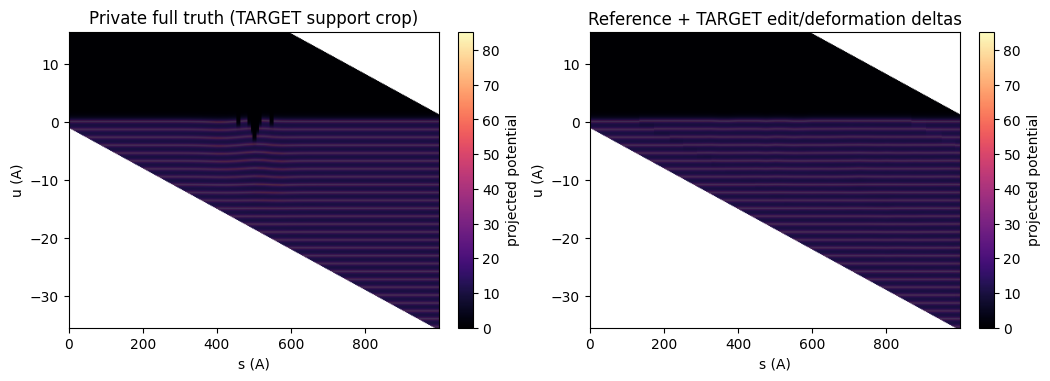

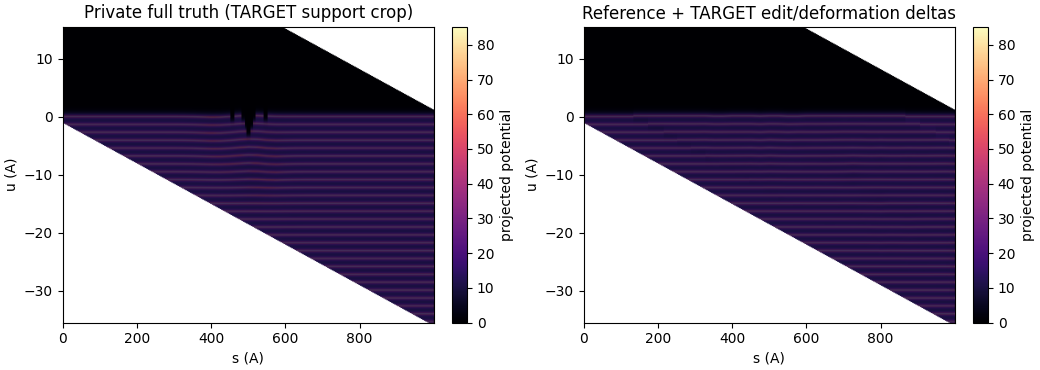

In [9]:
if ae_result is None:
    display({"TARGET-only reconstruction plot": "not generated", "reason": "AE reconstruction was not run"})
else:
    ae_target_figure = plot_silicon_atomistic_edit_run_1d(
        experiment,
        ae_run,
        truth_potential=np.asarray(dataset.potential),
    )
    display(ae_target_figure)


### 4.5 TARGET-only reconstruction evolution GIF

The reconstruction callback captures every meaningful AE-2 structural event: initialization, joint-refinement/prune/merge, accepted birth, projected polish, completed penalty-path point, and fixed-support debias. The GIF renders each captured event beside the post-selection private full-truth support crop. It does not interpolate states or claim to show the internal Adam sub-updates. Every reconstructed frame starts from the pristine reference, applies only TARGET host-site deformation/removal deltas and TARGET additions, and masks pixels outside authenticated TARGET influence.


{'TARGET-only evolution GIF': PosixPath('/home/dl277493/Documents/Code/WideAnglePropagation/notebook_results/sideview_glancing_ptychography_1d/atomistic_edit_evolution_strained_surface_defects.gif'),
 'captured structural events': 7,
 'rendered frames': 7,
 'all captured structural events rendered': True,
 'event phases': ('initial',
  'refinement',
  'polish',
  'refinement',
  'polish',
  'lambda_complete',
  'debias'),
 'fixed color scale across frames': True,
 'private truth used only after selection': True,
 'per-Adam-update history claimed': False}

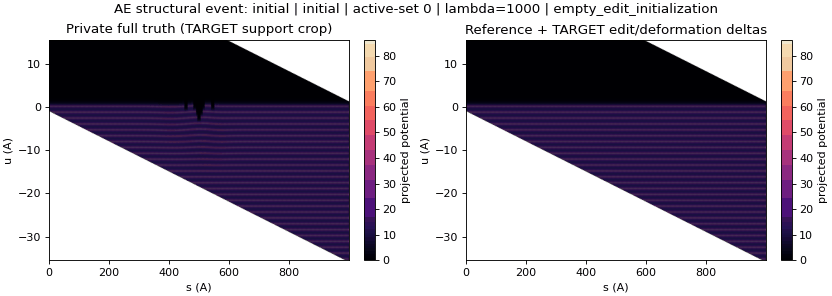

In [10]:
import io
import matplotlib.pyplot as plt
from IPython.display import Image as IPythonImage
from PIL import Image as PILImage

AE_EVOLUTION_DPI = 80
AE_EVOLUTION_FRAME_DURATION_MS = 900
AE_EVOLUTION_MAX_FRAMES = 2 + len(AE_EDIT_PENALTY_PATH) * (
    1 + 4 * AE_MAXIMUM_ACTIVE_SET_ITERATIONS
)  # initial + debias; at most four structural events/iteration + lambda_complete

if ae_result is None or not MAKE_ATOMISTIC_EDIT_EVOLUTION_GIF:
    display({
        "TARGET-only evolution GIF": "not generated",
        "reason": "AE reconstruction was not run" if ae_result is None else "MAKE_ATOMISTIC_EDIT_EVOLUTION_GIF=False",
    })
else:
    if not ae_progress_events:
        raise RuntimeError("AE solve returned without progress events")
    if len(ae_progress_events) > AE_EVOLUTION_MAX_FRAMES:
        raise RuntimeError(
            "bounded profile emitted more structural events than its declared GIF guard"
        )
    if ae_progress_events[0].phase != "initial" or ae_progress_events[-1].phase != "debias":
        raise RuntimeError("AE progress history is missing its initial or debias boundary")
    ae_frames = []
    ae_evolution_vmax = None
    for event in ae_progress_events:
        path_label = "initial" if event.path_index < 0 else f"path {event.path_index + 1}"
        selection_label = (
            " | validation-selected"
            if event.phase == "lambda_complete" and event.path_index == ae_result.selected_path_index
            else ""
        )
        event_label = (
            f"{event.phase} | {path_label} | active-set {event.active_set_iteration} "
            f"| lambda={event.edit_penalty:g} | {event.detail}{selection_label}"
        )
        figure = plot_silicon_atomistic_edit_run_1d(
            experiment,
            ae_run,
            state=event.state,
            truth_potential=np.asarray(dataset.potential),
        )
        image_axes = [axis for axis in figure.axes if axis.images]
        if ae_evolution_vmax is None:
            ae_evolution_vmax = max(axis.images[0].norm.vmax for axis in image_axes)
        for axis in image_axes:
            axis.images[0].set_clim(vmin=0.0, vmax=ae_evolution_vmax)
        figure.suptitle("AE structural event: " + event_label)
        buffer = io.BytesIO()
        figure.savefig(buffer, format="png", dpi=AE_EVOLUTION_DPI)
        buffer.seek(0)
        ae_frames.append(PILImage.open(buffer).convert("RGB").copy())
        plt.close(figure)
    ae_result_dir.mkdir(parents=True, exist_ok=True)
    ae_evolution_path = ae_result_dir / f"atomistic_edit_evolution_{dataset.case}.gif"
    ae_frames[0].save(
        ae_evolution_path,
        save_all=True,
        append_images=ae_frames[1:],
        duration=AE_EVOLUTION_FRAME_DURATION_MS,
        loop=0,
        optimize=False,
    )
    display({
        "TARGET-only evolution GIF": ae_evolution_path,
        "captured structural events": len(ae_progress_events),
        "rendered frames": len(ae_frames),
        "all captured structural events rendered": len(ae_frames) == len(ae_progress_events),
        "event phases": tuple(event.phase for event in ae_progress_events),
        "fixed color scale across frames": True,
        "private truth used only after selection": True,
        "per-Adam-update history claimed": False,
    })
    display(IPythonImage(filename=str(ae_evolution_path)))


### 4.6 Authenticated single-start evidence archive

The optional archive is a single-start AE-2 bundle, not a multistart consensus or acceptance certificate. It embeds the complete AE-1 model, calibrated acquisition, scan partitions, path states, objective components, KKT/capacity records, selected penalized state, and fixed-support debiased state. Loading uses `allow_pickle=False`, verifies SHA-256 and exact schemas, reconstructs the prepared problem, rerenders the specimen, and replays the objective evidence. The transient callback snapshots used by the GIF are not promoted to scientific evidence; their phase sequence and count enter only descriptive caller provenance.


In [ ]:
if ae_result is None or not SAVE_AND_RELOAD_ATOMISTIC_EDIT:
    display({
        "AE evidence archive": "not created",
        "reason": "AE reconstruction was not run" if ae_result is None else "SAVE_AND_RELOAD_ATOMISTIC_EDIT=False",
    })
else:
    ae_result_dir.mkdir(parents=True, exist_ok=True)
    ae_archive_path = ae_result_dir / "atomistic_edit_single_start.npz"
    save_silicon_atomistic_edit_run_1d(
        ae_archive_path,
        ae_run,
        provenance={
            "notebook_section": "sparse_atomistic_edit",
            "run_profile": AE_RUN_PROFILE,
            "data_boundary": "synthetic_noiseless_calibrated_counts",
            "progress_history": "truth_free_structural_events_not_Adam_subupdates",
            "progress_event_count": len(ae_progress_events),
            "progress_event_phases": [event.phase for event in ae_progress_events],
            "acceptance_claim": False,
        },
    )
    ae_loaded = load_silicon_atomistic_edit_run_1d(ae_archive_path)
    assert ae_loaded.prepared.reconstruction_problem_id == ae_prepared.reconstruction_problem_id
    assert ae_loaded.prepared.model.model_id == ae_prepared.model.model_id
    assert ae_loaded.result.active_parameter_count == ae_result.active_parameter_count
    display({
        "archive path": ae_archive_path,
        "archive SHA-256": ae_loaded.archive_id,
        "replayed prepared problem ID": ae_loaded.prepared.reconstruction_problem_id,
        "archive scope": "single start; no multistart or acceptance claim",
    })


## 5. Interpretation and remaining gates

Initializing a deformable Si host is a strong and explicit prior. It is fair only for the conditional question posed here: given known crystalline Si, registration, probe, calibration, and slab geometry, what sparse atomic changes are required by the counts? Empty edits and zero deformation do not reveal the generating defects, while the continuous positive centres make the representation broader than the vacancy-only truth used in this notebook. Their amplitudes are host-equivalent scattering, not elemental identities.

The committed bounded profile is executable and enabled, but it is not calibrated to pass the current complex case. An unconverged, KKT-violating, ambiguous, or capacity-limited result remains a reported failure. A low held-out deviance still cannot establish unique atomic structure. The current solver lacks a fitted calibrated probe/coherence nuisance block, continuous-space birth KKT, acquisition-bound depth observability, validation-equivalent multistart evidence, and the complete eight-case blind AE-3 result. The material-energy envelope remains blocked pending chemistry validation and metastable-defect ablation.

The TARGET-only figure and GIF are private synthetic diagnostics evaluated after selection. They prevent fitted NUISANCE support from being presented as recovered structure, but they are not available for experimental truth and do not enter inference. The authenticated archive makes the numerical claim replayable; it does not promote the result. Independent-atom Kirkland/Lobato checks validate declared numerical paths, not bonding, charge transfer, or experimental potential accuracy, and the blind cases still share downstream propagation. These physical and acquisition-level gates—not another object-specific shape prior—are the next evidence required.
